# COSC-4117EL A3 — Face Liveness Detection
## Training: ResNet-18 Transfer Learning

**Group 8**

This notebook:
1. Detects and crops faces from raw images using OpenCV Haar Cascade
2. Builds a stratified train/val/test split
3. Trains only the custom FC head on top of a frozen ResNet-18 backbone
4. Evaluates on the held-out test set: accuracy, precision, recall, F1, confusion matrix

> *Code assisted with Claude Code (Anthropic) — cited per course AI-use policy.*

In [ ]:
# Uncomment to install dependencies in a fresh environment
# %pip install torch torchvision opencv-python pillow scikit-learn matplotlib seaborn tqdm --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
import os
import random
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

print(f'PyTorch: {torch.__version__}')
print(f'OpenCV : {cv2.__version__}')

PyTorch: 2.11.0
OpenCV : 4.13.0


## Configuration

In [37]:
# ─────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────
CFG = {
    'data_dir':       'data',
    'processed_dir':  'data/processed',
    'models_dir':     'models',
    'image_size':     224,
    'batch_size':     32,
    'epochs':         25,
    'lr':             0.001,
    'weight_decay':   0.001,
    'patience':       5,
    'val_split':      0.15,
    'test_split':     0.15,
    'seed':           42,
    # ── Fine-tuning ──────────────────────────────────────
    # After this epoch, layer4 of the backbone is unfrozen.
    # It trains at lr/10 while the FC head continues at lr.
    'unfreeze_epoch': 5,
}

# label mapping: 0 = spoof, 1 = live
CLASS_NAMES   = {0: 'spoof', 1: 'live'}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG['seed'])

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

os.makedirs(CFG['models_dir'], exist_ok=True)
os.makedirs(os.path.join(CFG['processed_dir'], 'live'),  exist_ok=True)
os.makedirs(os.path.join(CFG['processed_dir'], 'spoof'), exist_ok=True)

print(f'Device : {DEVICE}')


Device : mps


## Step 1 — Face Detection & Preprocessing

OpenCV's Haar Cascade detector finds the largest face in each raw image.
The face is cropped with a 10 % padding on all sides, resized to 224 × 224,
and saved to `data/processed/`.
Images with no detected face fall back to a centre-square crop.
The step is **idempotent** — already-processed files are skipped.

In [38]:
def preprocess_dataset(
    data_dir: str,
    processed_dir: str,
    image_size: int = 224,
    padding: float = 0.10,
) -> dict:
    """
    Detect faces with OpenCV Haar Cascade and save 224x224 crops.
    Returns per-class stats dict.
    """
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )

    stats = {}
    for cls in ('live', 'spoof'):
        src = Path(data_dir) / cls
        dst = Path(processed_dir) / cls
        src_files = sorted(src.glob('*.png')) + sorted(src.glob('*.jpg'))
        n_src = len(src_files)

        already = len(list(dst.glob('*.png')))
        if already >= int(0.95 * n_src):
            print(f'[{cls}] {already}/{n_src} already processed — skipping.')
            stats[cls] = {'saved': already, 'fallback': 0}
            continue

        saved = fallback = 0
        print(f'[{cls}] Processing {n_src} images...')
        for p in tqdm(src_files, desc=cls):
            out = dst / p.name
            if out.exists():
                saved += 1
                continue

            img_bgr = cv2.imread(str(p))
            if img_bgr is None:
                continue
            h, w = img_bgr.shape[:2]

            gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(
                gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
            )

            if len(faces) > 0:
                # Use largest detected face
                x, y, fw, fh = max(faces, key=lambda f: f[2] * f[3])
                pad_x = int(padding * fw)
                pad_y = int(padding * fh)
                x1    = max(0, x - pad_x)
                y1    = max(0, y - pad_y)
                x2    = min(w, x + fw + pad_x)
                y2    = min(h, y + fh + pad_y)
                crop  = img_bgr[y1:y2, x1:x2]
            else:
                # Fallback: centre-square crop
                side = min(h, w)
                y0   = (h - side) // 2
                x0   = (w - side) // 2
                crop = img_bgr[y0:y0 + side, x0:x0 + side]
                fallback += 1

            if crop.size == 0:
                continue

            cv2.imwrite(str(out), cv2.resize(crop, (image_size, image_size)))
            saved += 1

        stats[cls] = {'saved': saved, 'fallback': fallback}
        print(f'  saved={saved}  fallback_crops={fallback}')

    return stats


stats = preprocess_dataset(CFG['data_dir'], CFG['processed_dir'], CFG['image_size'])
print('\nPreprocessing complete:', stats)

[live] Processing 1018 images...


live:   0%|          | 0/1018 [00:00<?, ?it/s]

  saved=1018  fallback_crops=543
[spoof] Processing 1015 images...


spoof:   0%|          | 0/1015 [00:00<?, ?it/s]

  saved=1015  fallback_crops=590

Preprocessing complete: {'live': {'saved': 1018, 'fallback': 543}, 'spoof': {'saved': 1015, 'fallback': 590}}


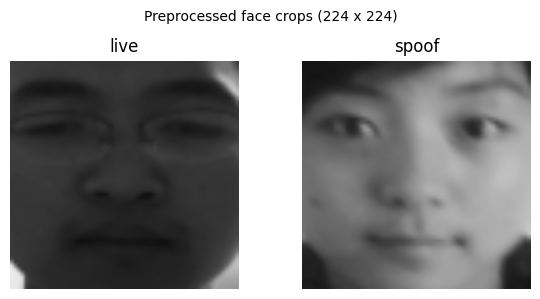

In [39]:
# Sanity check — show one live and one spoof crop
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, cls in zip(axes, ('live', 'spoof')):
    sample = next((Path(CFG['processed_dir']) / cls).glob('*.png'))
    img = cv2.cvtColor(cv2.imread(str(sample)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(cls, fontsize=12)
    ax.axis('off')
plt.suptitle('Preprocessed face crops (224 x 224)', fontsize=10)
plt.tight_layout()
plt.show()

## Step 2 — Dataset, Augmentation & DataLoaders

In [40]:
class LivenessDataset(Dataset):
    """Binary liveness dataset.  label 1 = live,  label 0 = spoof."""

    def __init__(self, paths, labels, transform=None):
        self.paths     = list(paths)
        self.labels    = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

In [41]:
# ── Transforms ──────────────────────────────────────────────────────────────
#
# Strong augmentation in the train set pushes the model to learn
# generalizable liveness cues (skin texture, 3-D lighting, reflection)
# rather than memorising the identity of the people in the training set.
#
train_tf = T.Compose([
    T.Resize((CFG['image_size'], CFG['image_size'])),
    # ── Geometry ──────────────────────────────────────────────────────────
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),                             # head tilt variation
    T.RandomPerspective(distortion_scale=0.15, p=0.4),       # viewing angle variation
    # ── Colour & lighting ─────────────────────────────────────────────────
    T.ColorJitter(brightness=0.4, contrast=0.4,
                  saturation=0.3, hue=0.08),                 # lighting changes
    T.RandomGrayscale(p=0.05),
    # ── Blur / noise — simulates focus, motion, compression ───────────────
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    # ── Tensor + normalise ────────────────────────────────────────────────
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    # ── Pixel-level dropout — prevents over-reliance on specific regions ──
    T.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.3, 3.0), value=0),
])

eval_tf = T.Compose([
    T.Resize((CFG['image_size'], CFG['image_size'])),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Collect all processed paths + labels ────────────────────────────────────
all_paths, all_labels = [], []
for label, cls in [(1, 'live'), (0, 'spoof')]:
    for p in sorted((Path(CFG['processed_dir']) / cls).glob('*.png')):
        all_paths.append(str(p))
        all_labels.append(label)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

# ── Stratified split: 70 / 15 / 15 ─────────────────────────────────────────
val_test = CFG['val_split'] + CFG['test_split']
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    all_paths, all_labels,
    test_size=val_test, stratify=all_labels, random_state=CFG['seed']
)
val_frac = CFG['val_split'] / val_test
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp,
    test_size=1 - val_frac, stratify=y_tmp, random_state=CFG['seed']
)

for name, y in [('train', y_tr), ('val', y_val), ('test', y_te)]:
    print(f'{name:5s}: {len(y):4d}  live={y.sum()}  spoof={len(y)-y.sum()}')

# ── DataLoaders ──────────────────────────────────────────────────────────────
train_ds = LivenessDataset(X_tr,  y_tr,  transform=train_tf)
val_ds   = LivenessDataset(X_val, y_val, transform=eval_tf)
test_ds  = LivenessDataset(X_te,  y_te,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0)


train: 1423  live=713  spoof=710
val  :  305  live=153  spoof=152
test :  305  live=152  spoof=153


## Step 3 — ResNet-18 Model

We load ImageNet-pretrained ResNet-18 and replace the final fully-connected layer:

```
Backbone  (frozen — weights never updated)
  └─ ...ResNet feature extractor...
Head  (trainable)
  ├─ Dropout(p=0.5)
  └─ Linear(512 → 2)          # live vs. spoof
```

Only the head parameters are passed to the optimizer.

In [42]:
def build_resnet18() -> nn.Module:
    """Pretrained ResNet-18 with a binary classification head. Backbone is frozen."""
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze entire backbone — weights will not be updated during training
    for p in model.parameters():
        p.requires_grad = False

    # Replace final FC layer — these are the only trainable parameters
    in_feats = model.fc.in_features  # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_feats, len(CLASS_NAMES)),
    )
    return model.to(DEVICE)


model = build_resnet18()

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters — total: {total:,}  trainable (FC head only): {trainable:,}')

Parameters — total: 11,177,538  trainable (FC head only): 1,026


## Step 4 — Training

Two-phase fine-tuning strategy:

| Phase | Epochs | Trainable layers | Learning rate |
|-------|--------|-----------------|---------------|
| 1 — warm-up | 1 → `unfreeze_epoch` | FC head only | `lr` |
| 2 — fine-tune | `unfreeze_epoch+1` → end | `layer4` + FC head | backbone: `lr/10`, head: `lr` |

Unfreezing only `layer4` (the deepest residual block, ~2.6 M params) lets the network adapt its highest-level features to the live/spoof task without disturbing the low-level texture and edge detectors in earlier layers. The lower learning rate for the backbone prevents catastrophic forgetting of the ImageNet features.


In [43]:
def _unfreeze_layer4(model: nn.Module) -> None:
    """Unfreeze layer4 and avgpool so they join the fine-tuning phase."""
    for name, p in model.named_parameters():
        if name.startswith('layer4') or name.startswith('avgpool'):
            p.requires_grad = True


def _make_optimizer(model: nn.Module, cfg: dict) -> optim.Optimizer:
    """
    Build an Adam optimizer with two parameter groups:
      • layer4 / avgpool  →  lr / 10   (gentle fine-tuning)
      • FC head           →  lr        (full learning rate)
    If layer4 is still frozen, only the head group is used.
    """
    backbone_params = [
        p for name, p in model.named_parameters()
        if p.requires_grad and not name.startswith('fc')
    ]
    head_params = list(model.fc.parameters())

    if backbone_params:
        param_groups = [
            {'params': backbone_params, 'lr': cfg['lr'] / 10},
            {'params': head_params,     'lr': cfg['lr']},
        ]
    else:
        param_groups = [{'params': head_params, 'lr': cfg['lr']}]

    return optim.Adam(param_groups, weight_decay=cfg['weight_decay'])


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    cfg: dict,
    save_path: str,
) -> dict:
    """
    Two-phase training:
      Phase 1 (epochs 1 – unfreeze_epoch)   : FC head only (backbone frozen)
      Phase 2 (epoch unfreeze_epoch+1 – end): layer4 + FC head (differential LRs)

    Returns history dict with train_loss, val_loss, val_acc lists.
    """
    criterion      = nn.CrossEntropyLoss()
    optimizer      = _make_optimizer(model, cfg)
    scheduler      = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg['epochs'], eta_min=1e-6
    )

    best_val_loss  = float('inf')
    patience_count = 0
    history        = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    phase          = 1

    for epoch in range(1, cfg['epochs'] + 1):

        # ── Phase transition: unfreeze layer4 ────────────────────────────────
        if phase == 1 and epoch > cfg['unfreeze_epoch']:
            phase = 2
            _unfreeze_layer4(model)
            optimizer = _make_optimizer(model, cfg)
            # Restart cosine schedule over the remaining epochs
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=cfg['epochs'] - epoch + 1, eta_min=1e-6
            )
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f'\n── Phase 2: layer4 unfrozen  '
                  f'(backbone LR={cfg["lr"]/10:.1e}, head LR={cfg["lr"]:.1e}, '
                  f'trainable params={trainable:,}) ──\n')

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch:02d} train  [phase {phase}]', leave=False):
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            # Clip gradients for all trainable parameters
            nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], max_norm=1.0
            )
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss = val_correct = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(DEVICE)
                labels = labels.to(DEVICE)
                out    = model(imgs)
                val_loss    += criterion(out, labels).item() * imgs.size(0)
                val_correct += (out.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc   = val_correct / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        scheduler.step()

        print(
            f'Epoch {epoch:02d}/{cfg["epochs"]}  '
            f'[phase {phase}]  '
            f'train_loss={train_loss:.4f}  '
            f'val_loss={val_loss:.4f}  '
            f'val_acc={val_acc:.4f}'
        )

        # ── Checkpoint ────────────────────────────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            torch.save({
                'epoch':       epoch,
                'state_dict':  model.state_dict(),
                'val_loss':    best_val_loss,
                'val_acc':     val_acc,
                'class_names': CLASS_NAMES,
                'image_size':  cfg['image_size'],
            }, save_path)
            print(f'  → Saved best model (val_loss={best_val_loss:.4f})')
        else:
            patience_count += 1
            if patience_count >= cfg['patience']:
                print(f'  Early stopping triggered at epoch {epoch}.')
                break

    return history


SAVE_PATH = os.path.join(CFG['models_dir'], 'resnet18_best.pth')
history   = train_model(model, train_loader, val_loader, CFG, SAVE_PATH)
print(f'\nBest model saved → {SAVE_PATH}')


Epoch 01 train  [phase 1]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 01/25  [phase 1]  train_loss=0.7725  val_loss=0.6342  val_acc=0.5869
  → Saved best model (val_loss=0.6342)


Epoch 02 train  [phase 1]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 02/25  [phase 1]  train_loss=0.6728  val_loss=0.5274  val_acc=0.7803
  → Saved best model (val_loss=0.5274)


Epoch 03 train  [phase 1]:   0%|          | 0/45 [00:00<?, ?it/s]

...

Epoch 14/25  [phase 2]  train_loss=0.1065  val_loss=0.2095  val_acc=0.9246


Epoch 15 train  [phase 2]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 15/25  [phase 2]  train_loss=0.0956  val_loss=0.1376  val_acc=0.9607


Epoch 16 train  [phase 2]:   0%|          | 0/45 [00:00<?, ?it/s]

Epoch 16/25  [phase 2]  train_loss=0.0918  val_loss=0.1362  val_acc=0.9607
  Early stopping triggered at epoch 16.

Best model saved → models/resnet18_best.pth


## Training Curves

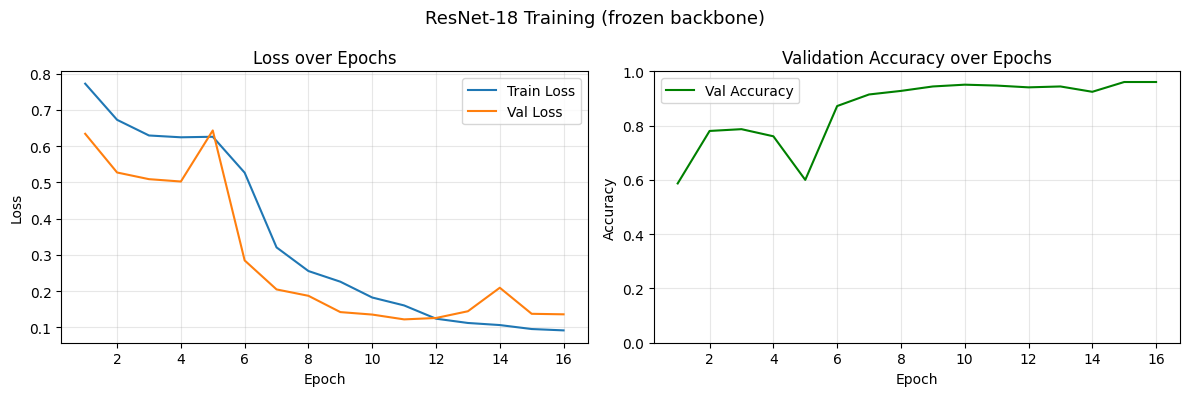

In [44]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, history['train_loss'], label='Train Loss')
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, history['val_acc'], color='green', label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('ResNet-18 Training (frozen backbone)', fontsize=13)
plt.tight_layout()
plt.savefig(
    os.path.join(CFG['models_dir'], 'resnet18_training_curves.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

## Step 5 — Test Set Evaluation

In [45]:
# Load best checkpoint
ckpt = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f"Loaded checkpoint — epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f}")

# Inference on test set
all_preds  = []
all_true   = []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        preds = model(imgs.to(DEVICE)).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_true.extend(labels.tolist())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

# Metrics
acc              = accuracy_score(all_true, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(all_true, all_preds, average='macro')

print(f'\n=== ResNet-18 Test Results ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}  (macro)')
print(f'Recall    : {rec:.4f}  (macro)')
print(f'F1 Score  : {f1:.4f}  (macro)')
print()
print(classification_report(all_true, all_preds, target_names=['spoof', 'live']))

# Save results for experiments notebook
import json
result_path = os.path.join(CFG['models_dir'], 'resnet18_test_results.json')
with open(result_path, 'w') as f:
    json.dump({
        'model':     'ResNet-18',
        'accuracy':  float(acc),
        'precision': float(prec),
        'recall':    float(rec),
        'f1':        float(f1),
    }, f, indent=2)
print(f'Results saved → {result_path}')

Loaded checkpoint — epoch 11, val_loss=0.1222


Testing:   0%|          | 0/10 [00:00<?, ?it/s]


=== ResNet-18 Test Results ===
Accuracy  : 0.9705
Precision : 0.9710  (macro)
Recall    : 0.9705  (macro)
F1 Score  : 0.9705  (macro)

              precision    recall  f1-score   support

       spoof       0.99      0.95      0.97       153
        live       0.96      0.99      0.97       152

    accuracy                           0.97       305
   macro avg       0.97      0.97      0.97       305
weighted avg       0.97      0.97      0.97       305

Results saved → models/resnet18_test_results.json


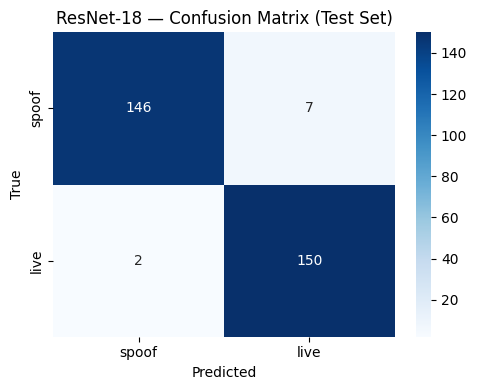

In [46]:
# Confusion matrix
cm  = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['spoof', 'live'],
    yticklabels=['spoof', 'live'],
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('ResNet-18 — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig(
    os.path.join(CFG['models_dir'], 'resnet18_confusion_matrix.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()